# Memory & States

#### Ignoring the Warning

In [2]:
import warnings
warnings.filterwarnings("ignore", message="Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.")

Google recently updated their SDK to recommend using a different method (Chat.send_message) for agents that use tools or function calling. Because LangChain's internal code hasn't fully migrated to this new method yet, Google's SDK prints this warning.

In [11]:
from dotenv import load_dotenv
from pprint import pprint
from langchain.agents import create_agent
from langchain.messages import HumanMessage

agent = create_agent(model="google_genai:gemini-2.5-flash")

result = agent.invoke({"messages": [HumanMessage(content= "My name is Kamran. My favourite color is black.")]})

print(result['messages'][-1].content)

Nice to meet you, Kamran! Black is a really classic and versatile color.


### Problem

In [12]:
result = agent.invoke({"messages": [HumanMessage(content= "What is my favourite color.")]})

print(result['messages'][-1].content)

As an AI, I don't have access to personal information about you, so I don't know what your favorite color is!

You'll have to tell me! What is it? 😊


### Solution

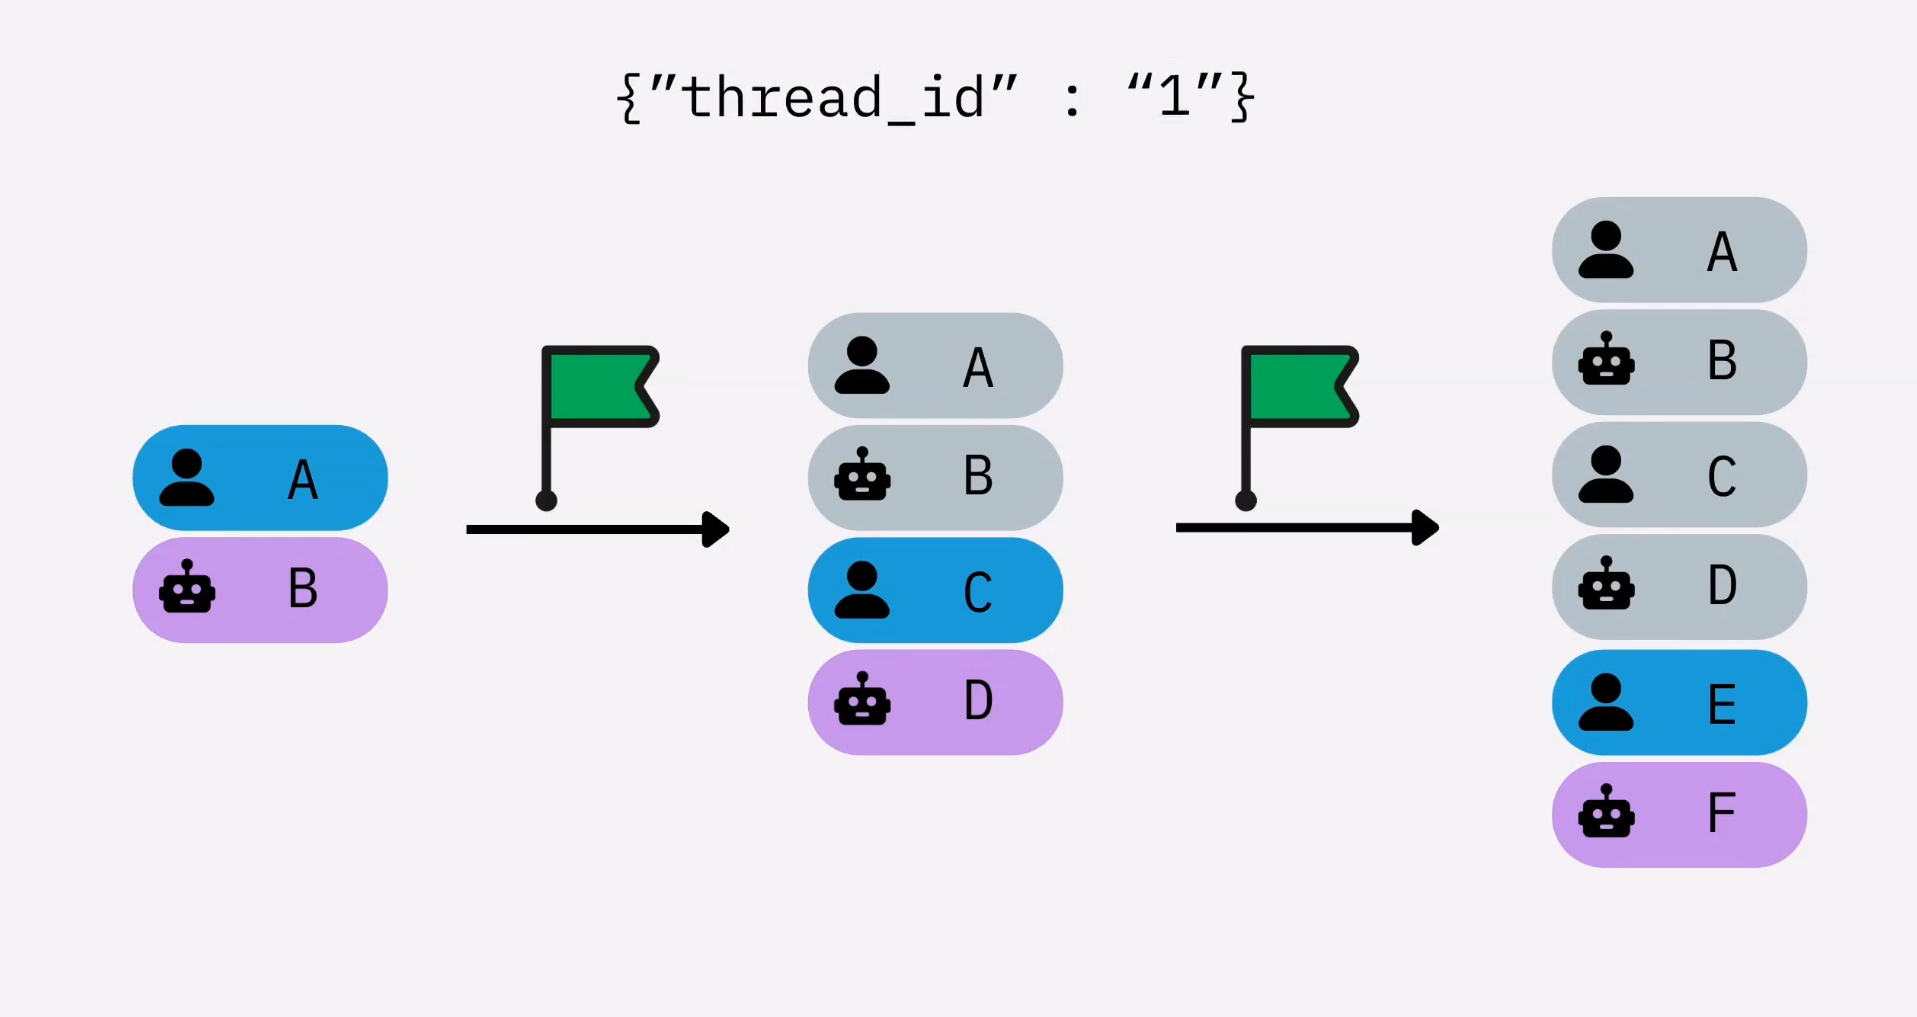

In [6]:
from langgraph.checkpoint.memory import InMemorySaver  


agent = create_agent(
    "google_genai:gemini-2.5-flash",
    checkpointer=InMemorySaver(),  
)

# Setting a thread id
config = {"configurable": {"thread_id": "1"}}

question = HumanMessage(content= "My name is Kamran. My favourite color is black.")

result = agent.invoke({"messages": [question]}, config)

print(result['messages'][-1].content)

Hi Kamran! Thanks for letting me know your favorite color is black.


In [10]:
question2 = HumanMessage(content= "What is my favourite color.")

result = agent.invoke({"messages": [question2]}, config)

print(result['messages'][-1].content)

Your favorite color is **black**.
